In [1]:
# 변수의 shape, type, value 확인
def p(var) :
    if type(var)!=type([]):
        try: 
            print(f'Shape:{var.shape}')
        except : 
            pass
    print(f'Type: {type(var)}')
    print(f'Values: {var}')

def pst(_x,_name=""):
    print(f'[{_name}] Shape{_x.shape}, {type(_x)}')
def ps(_x,_name=""):
    print(f'[{_name}] Shape{_x.shape}')

In [2]:
%%capture
!pip install pytorch_lightning torchinfo torchmetrics pandas torchviz

## infoGAN

In [3]:
import torch
from torch import nn
from torch.nn import functional as F
from torch.utils.data import Dataset, DataLoader
from torchinfo import summary
from torchviz import make_dot
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
from IPython import display

device = 'cuda:0'
torch.__version__

'1.13.1+cu116'

### Dataset 준비

- model params

In [4]:
BUFFER_SIZE = 60000
BATCH_SIZE = 600
EPOCHS = 100
latent_code_dim=10  ## latent code 
noise_dim = 90      ## z-vector 
IN_PUT_DIM=latent_code_dim+noise_dim
num_examples_to_generate = 16
IMG_SHAPE=(1,28,28)

In [5]:
import torchvision.transforms as transforms
from torchvision.datasets import FashionMNIST, MNIST

class Normalize(object):        
    def __call__(self, sample):
        sample = np.array(sample)
        image = (sample - 127.5) / 127.5
        return torch.FloatTensor(image).unsqueeze(dim=0)

class Onehot(object):        
    def __call__(self, sample):
        sample = sample
        target = np.eye(10)[sample]
        return torch.FloatTensor(target)
        
# Normalize data to [-1 ~ 1]
mnist_transform = transforms.Compose([
    Normalize(), # noise add
])
target_transform = transforms.Compose([
    Onehot(), # noise add
])

# download path 정의
download_root = './MNIST_DATASET'
train_dataset = MNIST(download_root, transform=mnist_transform, train=True, download=True, target_transform=target_transform)
test_dataset = MNIST(download_root, transform=mnist_transform, train=False, download=True, target_transform=target_transform)

  0%|          | 0/9912422 [00:00<?, ?it/s]

Extracting ./MNIST_DATASET/MNIST/raw/train-images-idx3-ubyte.gz to ./MNIST_DATASET/MNIST/raw



  0%|          | 0/28881 [00:00<?, ?it/s]

Extracting ./MNIST_DATASET/MNIST/raw/train-labels-idx1-ubyte.gz to ./MNIST_DATASET/MNIST/raw



  0%|          | 0/1648877 [00:00<?, ?it/s]

Extracting ./MNIST_DATASET/MNIST/raw/t10k-images-idx3-ubyte.gz to ./MNIST_DATASET/MNIST/raw



  0%|          | 0/4542 [00:00<?, ?it/s]

Extracting ./MNIST_DATASET/MNIST/raw/t10k-labels-idx1-ubyte.gz to ./MNIST_DATASET/MNIST/raw



tensor([0., 0., 0., 0., 0., 1., 0., 0., 0., 0.])


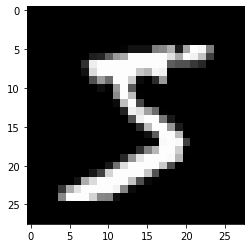

In [ ]:
plt.imshow(train_dataset[0][0][0, :, :], cmap='gray')
print(train_dataset[0][1])

In [ ]:
train_dataloader = DataLoader(train_dataset, BATCH_SIZE, True)
test_dataloader = DataLoader(test_dataset, BATCH_SIZE, False)

### Model define

In [ ]:
# InfoGenerator model
class InfoGenerator(nn.Module):
    def __init__(self, input_dim):
        super(InfoGenerator, self).__init__()
        self.generator = nn.Sequential(
            nn.Linear(input_dim, 256 * 7 * 7, bias=False),
            nn.Unflatten(1, (256, 7, 7)),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(),
            nn.ConvTranspose2d(256, 128, 5, 1, padding=2, bias=False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(),
            nn.ConvTranspose2d(128, 64, 5, 2, padding=2, output_padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(),
            nn.ConvTranspose2d(64, 1, 5, 2, padding=2, output_padding=1, bias=False),
            #정답이미지를 -1~1의 범위를 갖도록 normalrize해서 출력층의 활성함수는 tanh로 결정
            nn.Tanh()
        )
        
    def forward(self, noise, label, code1, code2):
        noise = noise.to(device)
        label = label.to(device)
        code1 = code1.to(device)
        code2 = code2.to(device)
        inputs = torch.cat([noise, label, code1, code2], dim=1)
        out = self.generator(inputs)
        return out

z_vector = torch.randn((BATCH_SIZE, noise_dim), device=device)
info_generator = InfoGenerator(noise_dim+latent_code_dim+1+1).to(device)
summary(info_generator, input_size=[(BATCH_SIZE, noise_dim), 
                                    (BATCH_SIZE, latent_code_dim), 
                                    (BATCH_SIZE, 1), 
                                    (BATCH_SIZE, 1)])

Layer (type:depth-idx)                   Output Shape              Param #
InfoGenerator                            --                        --
├─Sequential: 1-1                        [600, 1, 28, 28]          --
│    └─Linear: 2-1                       [600, 12544]              1,279,488
│    └─Unflatten: 2-2                    [600, 256, 7, 7]          --
│    └─BatchNorm2d: 2-3                  [600, 256, 7, 7]          512
│    └─LeakyReLU: 2-4                    [600, 256, 7, 7]          --
│    └─ConvTranspose2d: 2-5              [600, 128, 7, 7]          819,200
│    └─BatchNorm2d: 2-6                  [600, 128, 7, 7]          256
│    └─LeakyReLU: 2-7                    [600, 128, 7, 7]          --
│    └─ConvTranspose2d: 2-8              [600, 64, 14, 14]         204,800
│    └─BatchNorm2d: 2-9                  [600, 64, 14, 14]         128
│    └─LeakyReLU: 2-10                   [600, 64, 14, 14]         --
│    └─ConvTranspose2d: 2-11             [600, 1, 28, 28]        

In [ ]:
make_dot(info_generator(torch.zeros(BATCH_SIZE, noise_dim).to(device), 
                        torch.zeros(BATCH_SIZE, latent_code_dim).to(device), 
                        torch.zeros(BATCH_SIZE, 1).to(device), 
                        torch.zeros(BATCH_SIZE, 1).to(device)), 
         params=dict(info_generator.named_parameters())).render("info_generator", format="png")

'info_generator.png'

In [ ]:
# InfoDiscriminator model
class InfoDiscriminator(nn.Module):
    def __init__(self, label_dim):
        super(InfoDiscriminator, self).__init__()
        self.discriminator = nn.Sequential(
            nn.Conv2d(1, 64, 5, 2, padding=2),
            nn.LeakyReLU(),
            nn.Conv2d(64, 128, 5, 2, padding=2),
            nn.LeakyReLU(),
            nn.Flatten()
        )
        self.discLinear = nn.Sequential(
            nn.Linear(128*7*7, 1),
            nn.Sigmoid()
        )
        self.firstLinear = nn.Linear(128*7*7, 128)
        self.acLinear = nn.Linear(128, label_dim)
      
        self.code1Linear = nn.Sequential(
            nn.Linear(128, 1),
            nn.Sigmoid()
        )
        self.code2Linear = nn.Sequential(
            nn.Linear(128, 1),
            nn.Sigmoid()
        )
    def forward(self, x):
        out = self.discriminator(x)
        disc_out = self.discLinear(out)

        out2 = self.firstLinear(out)
        label_out = self.acLinear(out2)
        
        code1 = self.code1Linear(out2)
        code2 = self.code2Linear(out2)
        return disc_out, label_out, code1, code2

info_discriminator = InfoDiscriminator(latent_code_dim).to(device)
summary(info_discriminator, input_size=[(BATCH_SIZE, 1, 28, 28)])

Layer (type:depth-idx)                   Output Shape              Param #
InfoDiscriminator                        --                        --
├─Sequential: 1-1                        [600, 6272]               --
│    └─Conv2d: 2-1                       [600, 64, 14, 14]         1,664
│    └─LeakyReLU: 2-2                    [600, 64, 14, 14]         --
│    └─Conv2d: 2-3                       [600, 128, 7, 7]          204,928
│    └─LeakyReLU: 2-4                    [600, 128, 7, 7]          --
│    └─Flatten: 2-5                      [600, 6272]               --
├─Sequential: 1-2                        [600, 1]                  --
│    └─Linear: 2-6                       [600, 1]                  6,273
│    └─Sigmoid: 2-7                      [600, 1]                  --
├─Linear: 1-3                            [600, 128]                802,944
├─Linear: 1-4                            [600, 10]                 1,290
├─Sequential: 1-5                        [600, 1]                 

In [ ]:
make_dot(info_discriminator(torch.zeros(BATCH_SIZE, 1, 28, 28).to(device)), 
         params=dict(info_discriminator.named_parameters())).render("info_discriminator", format="png")

'info_discriminator.png'

In [ ]:
class InfoGAN(nn.Module):
    def __init__(self, generator, discriminator):
        super(InfoGAN, self).__init__()
        self.generator = generator
        self.discriminator = discriminator
        
    def forward(self, noise, label, code1, code2):
        fake_img = self.generator(noise, label, code1, code2)
        out_disc, out_label, out_code1, out_code2 = self.discriminator(fake_img)
        return out_disc, out_label, out_code1, out_code2

info_gan = InfoGAN(generator=info_generator, discriminator=info_discriminator).to(device)
summary(info_gan, 
        input_size=[(BATCH_SIZE, noise_dim),
                    (BATCH_SIZE, latent_code_dim),
                    (BATCH_SIZE, 1),
                    (BATCH_SIZE, 1)])

Layer (type:depth-idx)                   Output Shape              Param #
InfoGAN                                  --                        --
├─InfoGenerator: 1-1                     [600, 1, 28, 28]          --
│    └─Sequential: 2-1                   [600, 1, 28, 28]          --
│    │    └─Linear: 3-1                  [600, 12544]              1,279,488
│    │    └─Unflatten: 3-2               [600, 256, 7, 7]          --
│    │    └─BatchNorm2d: 3-3             [600, 256, 7, 7]          512
│    │    └─LeakyReLU: 3-4               [600, 256, 7, 7]          --
│    │    └─ConvTranspose2d: 3-5         [600, 128, 7, 7]          819,200
│    │    └─BatchNorm2d: 3-6             [600, 128, 7, 7]          256
│    │    └─LeakyReLU: 3-7               [600, 128, 7, 7]          --
│    │    └─ConvTranspose2d: 3-8         [600, 64, 14, 14]         204,800
│    │    └─BatchNorm2d: 3-9             [600, 64, 14, 14]         128
│    │    └─LeakyReLU: 3-10              [600, 64, 14, 14]       

In [ ]:
make_dot(info_gan(torch.zeros(BATCH_SIZE, noise_dim).to(device), 
                        torch.zeros(BATCH_SIZE, latent_code_dim).to(device), 
                        torch.zeros(BATCH_SIZE, 1).to(device), 
                        torch.zeros(BATCH_SIZE, 1).to(device)), 
         params=dict(info_gan.named_parameters())).render("info_gan", format="png")

'info_gan.png'

### Model 생성 및 학습조건 설정

In [ ]:
### mutual information 계산 
# noise z와 code c를 가지고 생성한 이미지 x
# 이미지 x로 부터 구한 코드 c' 
# c분포와 c'분포의 cross entropy 계산 
# mi_loss = - c * log(Q(c|x))

def mi_loss(q_of_c_given_x, c):
    r = -torch.mean(torch.sum(
        c * torch.log(
            q_of_c_given_x + 1e-7
        ), dim=1
    ))
    return r

In [ ]:
lr = 2e-4
bce_loss_function = nn.BCELoss()
cce_loss_function = nn.CrossEntropyLoss()
mi_loss_function = mi_loss
info_generator = info_generator.to(device)
info_discriminator = info_discriminator.to(device)
optimizer_discriminator = torch.optim.Adam(info_discriminator.parameters(), lr=lr)
optimizer_generator = torch.optim.Adam(info_generator.parameters(), lr=lr)

In [ ]:
def generate_and_save_images(model, epoch):
    r, c = 10, 10
    fig, axs = plt.subplots(r, c)
    for i in range(c):
        noise_input = torch.randn((r, noise_dim)).to(device)
        noise_label = torch.FloatTensor(np.eye(r, 10)[np.full(fill_value=i, shape=(r))]).to(device)
        code_std = 2
        a = torch.linspace(-code_std, code_std, 10).view(-1, 1).to(device)
        noise_code1 = torch.ones((10, 1)).to(device) * a
        a = torch.linspace(-code_std, code_std, 10).view(-1, 1).to(device)
        noise_code2 = torch.ones((10, 1)).to(device) * a

        gen_imgs = model(noise_input, noise_label, noise_code1, noise_code2)###
        gen_imgs = 0.5 * gen_imgs + 0.5  # (0~1)<-(-1~1) scaling
        for j in range(r):
            axs[j,i].imshow(gen_imgs.cpu().detach().numpy()[j,0,:,:], cmap='gray')
            axs[j,i].axis('off')
    plt.savefig('image_at_epoch_{:04d}.png'.format(epoch))
    plt.show()

### Training

#CPU times: user 34min 21s, sys: 2min 13s, total: 36min 35s  
#Wall time: 48min 34s

Epoch: 0 Loss D.: 1.6758129596710205
Epoch: 0 Loss G.: 3.490095376968384


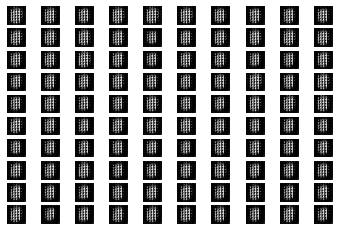

Epoch: 10 Loss D.: -2.9943559169769287
Epoch: 10 Loss G.: -4.448766231536865


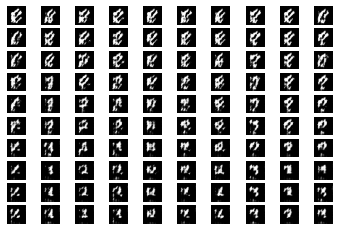

Epoch: 20 Loss D.: -2.861424446105957
Epoch: 20 Loss G.: -4.810024261474609


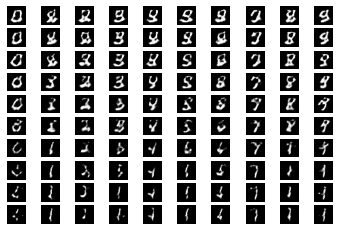

Epoch: 30 Loss D.: -3.131476879119873
Epoch: 30 Loss G.: -4.694086074829102


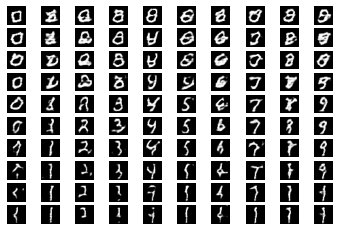

Epoch: 40 Loss D.: -2.511563301086426
Epoch: 40 Loss G.: -4.220033645629883


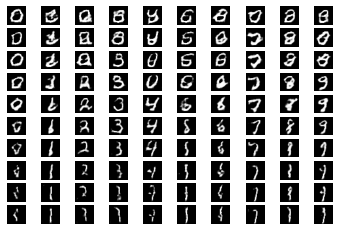

Epoch: 50 Loss D.: -2.7798874378204346
Epoch: 50 Loss G.: -5.170966148376465


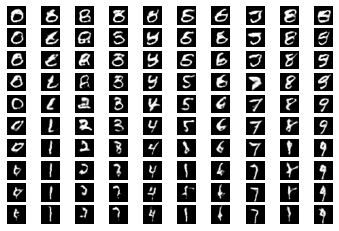

Epoch: 60 Loss D.: -2.6939945220947266
Epoch: 60 Loss G.: -5.172375679016113


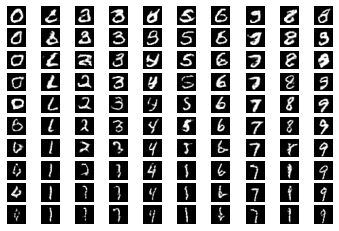

Epoch: 70 Loss D.: -2.828132390975952
Epoch: 70 Loss G.: -4.91602087020874


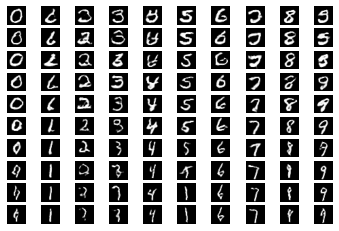

Epoch: 80 Loss D.: -2.7622318267822266
Epoch: 80 Loss G.: -5.407013893127441


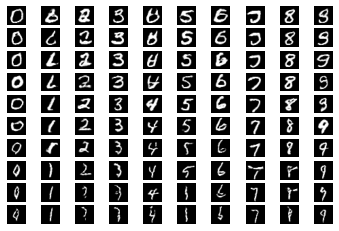

Epoch: 90 Loss D.: -2.6003825664520264
Epoch: 90 Loss G.: -4.686837673187256


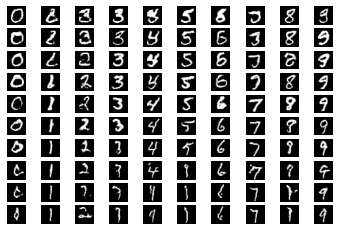

CPU times: user 12min 41s, sys: 4.06 s, total: 12min 45s
Wall time: 12min 46s


In [ ]:
%%time
for epoch in range(EPOCHS):
    for image_batch, real_label in train_dataloader:
        image_batch = image_batch.to(device)
        real_label = real_label.to(device)
        yb_real = torch.Tensor(BATCH_SIZE,1).fill_(1.0).to(device) # real_label
        yb_fake = torch.Tensor(BATCH_SIZE,1).fill_(0.0).to(device) # fake_label
        # real latent_code :  무작위
        real_code1=torch.randn([BATCH_SIZE, 1]).to(device)
        real_code2=torch.randn([BATCH_SIZE, 1]).to(device)

        # Generator
        info_generator.zero_grad()
        noise = torch.randn((BATCH_SIZE, noise_dim)).to(device)
        fakelabel = np.random.randint(0, 10, BATCH_SIZE)
        fakelabel = torch.FloatTensor(np.eye(BATCH_SIZE, 10)[fakelabel]).to(device)
        fake_code1=torch.randn([BATCH_SIZE, 1]).to(device)
        fake_code2=torch.randn([BATCH_SIZE, 1]).to(device)

        # 가짜 이미지 생성
        fake_img = info_generator(noise, fakelabel, fake_code1, fake_code2)
        # 가짜 이미지 판별
        dis_out, label_out, code1_out, code2_out = info_discriminator(fake_img)
        loss_gen_bce = bce_loss_function(dis_out, yb_real)
        loss_gen_cce = cce_loss_function(label_out, fakelabel)
        loss_gen_mi = mi_loss_function(code1_out, fake_code1) * 0.5 + mi_loss_function(code2_out, fake_code2) * 0.5
        loss_gen = loss_gen_bce + loss_gen_cce + loss_gen_mi
        loss_gen.backward()
        optimizer_generator.step()

        # Discriminator
        info_discriminator.zero_grad()
        
        # 진짜 이미지 판별
        dis_out, label_out, code1_out, code2_out = info_discriminator(image_batch)
        loss_real_bce = bce_loss_function(dis_out, yb_real)
        loss_real_cce = cce_loss_function(label_out, real_label)
        loss_real_mi = mi_loss_function(code1_out, real_code1) * 0.5 + mi_loss_function(code2_out, real_code2) * 0.5
        loss_real = loss_real_bce + loss_real_cce + loss_real_mi

        # 가짜 이미지 판별
        dis_out, label_out, code1_out, code2_out = info_discriminator(fake_img.detach())
        loss_fake_bce = bce_loss_function(dis_out, yb_fake)
        loss_fake_cce = cce_loss_function(label_out, fakelabel)
        loss_fake_mi = mi_loss_function(code1_out, fake_code1) * 0.5 + mi_loss_function(code2_out, fake_code2) * 0.5
        loss_fake = loss_fake_bce + loss_fake_cce + loss_fake_mi

        loss_dis = (loss_real + loss_fake) / 2
        loss_dis.backward()
        optimizer_discriminator.step()
  
    if epoch % 10 ==0:
        print(f"Epoch: {epoch} Loss D.: {loss_dis}")
        print(f"Epoch: {epoch} Loss G.: {loss_gen}")
        generate_and_save_images(info_generator, epoch)

In [ ]:
torch.save(info_generator, 'infoGANgenerator2.pt')

In [ ]:
#!cp -r ./infoGANgenerator/ /gdrive/MyDrive/models/infoGANgenerator/

- Model load

In [ ]:
generator = torch.save('infoGANgenerator2.pt') 

### latent code1,2 특징 확인

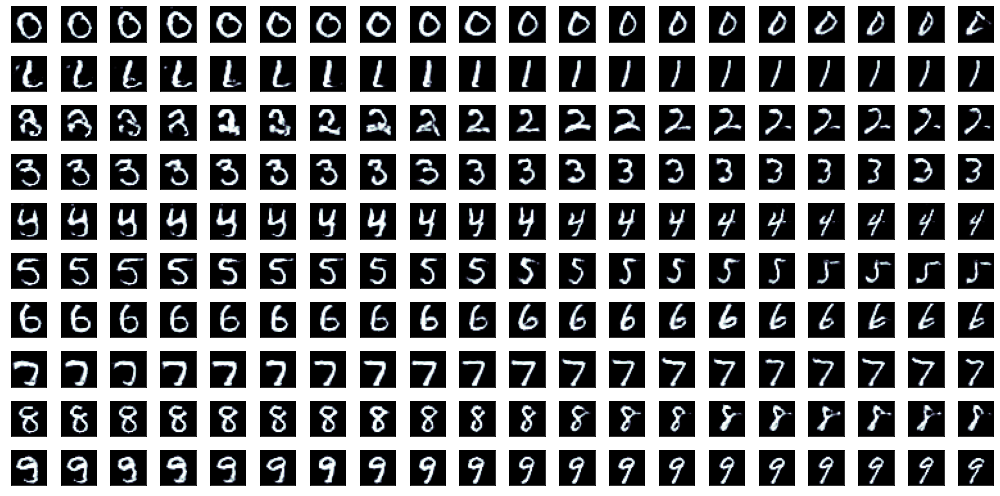

In [ ]:
r, c = 10, 20
code1_l = -0   # -15  #code1_min
code1_h = 0   # 15    #code1_max
code2_l = -2   # -7   #code2_min
code2_h = 2   # 20   #code2_max

fig = plt.figure(figsize=(14,7))
plt.subplots_adjust(top=0.99, bottom=0.01, left=0.01,right=0.99)
for i in range(r):
    noise_input = torch.rand([c, noise_dim]).to(device) # (20,90)
    noise_label = torch.FloatTensor(np.eye(10)[np.full(fill_value=i, shape=(c,))]).to(device)   # class label (20,10)
    noise_code1 = torch.linspace(code1_l, code1_h, c).view(c, 1).to(device)                  # latent_code1 (20, 1)
    noise_code2 = torch.linspace(code2_l, code2_h, c).view(c, 1).to(device)                  # latent_code2 (20, 1)

    # 20개 이미지 추론           ([(20,90),(20,10),(20,1),(20,1)]) 
    gen_imgs = info_generator(noise_input, noise_label, noise_code1, noise_code2)
    gen_imgs = 0.5 * gen_imgs + 0.5  # (0~1)<-(-1~1) scaling
    for j in range(c): # 20개 이미지 출력
        ax = fig.add_subplot(r, c, i * c + j + 1)
        ax.imshow(gen_imgs.cpu().detach().numpy()[j,0,:,:], cmap=plt.cm.bone)
        ax.xaxis.set_ticks([])
        ax.yaxis.set_ticks([])
plt.tight_layout()
plt.show()

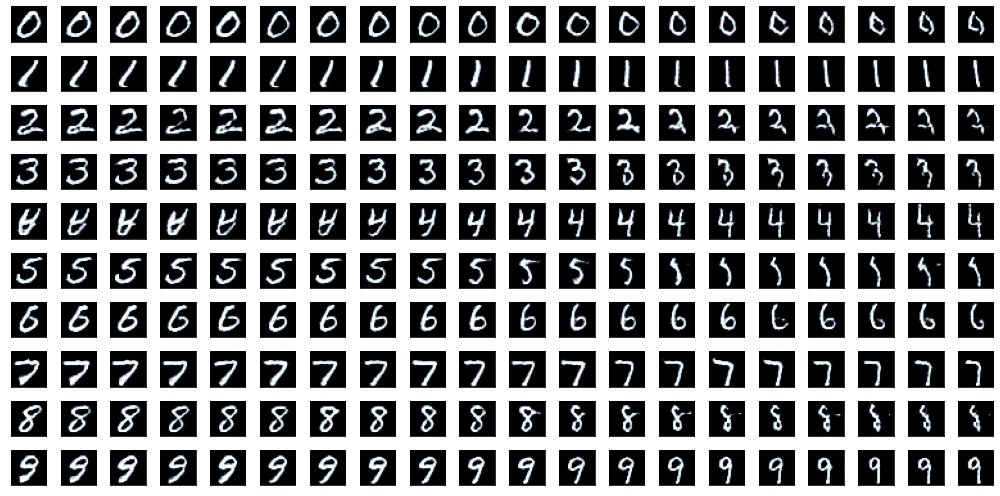

In [ ]:
r, c = 10, 20
code1_l = -2   # -15  #code1_min
code1_h = 2   # 15    #code1_max
code2_l = -0   # -7   #code2_min
code2_h = 0   # 20   #code2_max

fig = plt.figure(figsize=(14,7))
plt.subplots_adjust(top=0.99, bottom=0.01, left=0.01,right=0.99)
for i in range(r):
    noise_input = torch.rand([c, noise_dim]).to(device) # (20,90)
    noise_label = torch.FloatTensor(np.eye(10)[np.full(fill_value=i, shape=(c,))]).to(device)   # class label (20,10)
    noise_code1 = torch.linspace(code1_l, code1_h, c).view(c, 1).to(device)                  # latent_code1 (20, 1)
    noise_code2 = torch.linspace(code2_l, code2_h, c).view(c, 1).to(device)                  # latent_code2 (20, 1)

    # 20개 이미지 추론           ([(20,90),(20,10),(20,1),(20,1)]) 
    gen_imgs = info_generator(noise_input, noise_label, noise_code1, noise_code2)
    gen_imgs = 0.5 * gen_imgs + 0.5  # (0~1)<-(-1~1) scaling
    for j in range(c): # 20개 이미지 출력
        ax = fig.add_subplot(r, c, i * c + j + 1)
        ax.imshow(gen_imgs.cpu().detach().numpy()[j,0,:,:], cmap=plt.cm.bone)
        ax.xaxis.set_ticks([])
        ax.yaxis.set_ticks([])
plt.tight_layout()
plt.show()

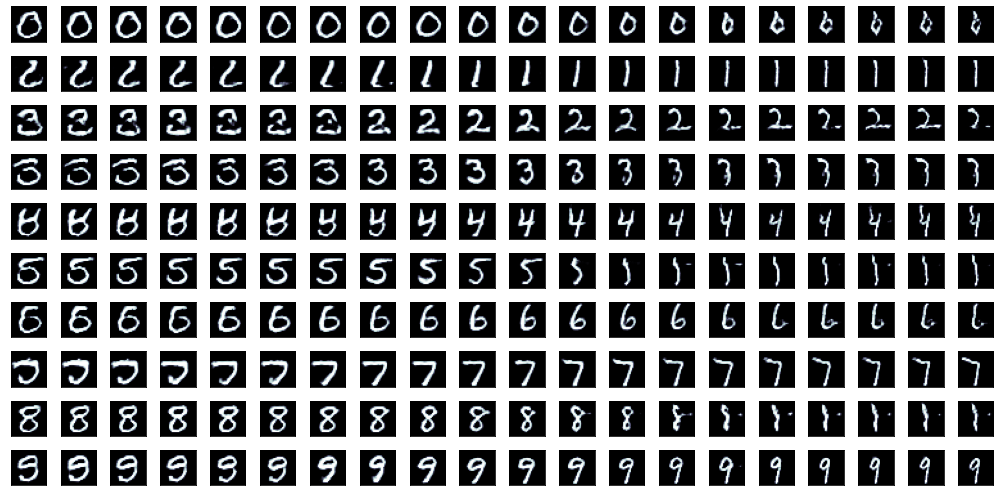

In [ ]:
r, c = 10, 20
code1_l = -2   # -15  #code1_min
code1_h = 2   # 15    #code1_max
code2_l = -2   # -7   #code2_min
code2_h = 2   # 20   #code2_max

fig = plt.figure(figsize=(14,7))
plt.subplots_adjust(top=0.99, bottom=0.01, left=0.01,right=0.99)
for i in range(r):
    noise_input = torch.rand([c, noise_dim]).to(device) # (20,90)
    noise_label = torch.FloatTensor(np.eye(10)[np.full(fill_value=i, shape=(c,))]).to(device)   # class label (20,10)
    noise_code1 = torch.linspace(code1_l, code1_h, c).view(c, 1).to(device)                  # latent_code1 (20, 1)
    noise_code2 = torch.linspace(code2_l, code2_h, c).view(c, 1).to(device)                  # latent_code2 (20, 1)

    # 20개 이미지 추론           ([(20,90),(20,10),(20,1),(20,1)]) 
    gen_imgs = info_generator(noise_input, noise_label, noise_code1, noise_code2)
    gen_imgs = 0.5 * gen_imgs + 0.5  # (0~1)<-(-1~1) scaling
    for j in range(c): # 20개 이미지 출력
        ax = fig.add_subplot(r, c, i * c + j + 1)
        ax.imshow(gen_imgs.cpu().detach().numpy()[j,0,:,:], cmap=plt.cm.bone)
        ax.xaxis.set_ticks([])
        ax.yaxis.set_ticks([])
plt.tight_layout()
plt.show()